# LSTM: Long Short-Term Memory

Librerias necesarias 

In [ ]:
# Librerias necesarias 
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Bidirectional, Dropout, Masking
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

## Funciones 

A continuación, definiremos las funciones que usaremos en el notebook 

Esta primera función `plot_kfold_history_keras` grafica la pérdida y la precisión promedio de los 5 folds con sombra de desviación estándar.

In [ ]:
import matplotlib.pyplot as plt

def plot_kfold_history_keras(fold_histories, title='Métricas K-Fold LSTM'):
    """
    Grafica Loss y Accuracy promedio de los 5 folds con sombra de desviación estándar.
    """
    
    if not fold_histories:
        print("Error: No hay historias para graficar.")
        return

    # Encontrar la longitud mínima (por si hubo Early Stopping en tiempos distintos)
    # Cortamos todas las gráficas a la longitud del entrenamiento más corto
    # Opcional: Podrías rellenar con NaNs, pero cortar es más limpio para visualizar.
    min_epochs = min(len(h['loss']) for h in fold_histories)
    
    print(f"Graficando las primeras {min_epochs} épocas comunes...")

    # Crear arrays para promedios
    metrics_map = {
        'loss': 'loss', 
        'val_loss': 'val_loss', 
        'acc': 'accuracy',           # <--- CAMBIO IMPORTANTE
        'val_acc': 'val_accuracy'    # <--- CAMBIO IMPORTANTE
    }
    
    data = {k: np.zeros((len(fold_histories), min_epochs)) for k in metrics_map.keys()}

    # 3. Rellenar datos recortando al mínimo común
    for i, history in enumerate(fold_histories):
        for key_out, key_in in metrics_map.items():
            # key_out es 'acc' (para el plot), key_in es 'accuracy' (lo que viene de Keras)
            if key_in in history:
                data[key_out][i, :] = history[key_in][:min_epochs]
            else:
                print(f"⚠️ Warning: Métrica '{key_in}' no encontrada en el historial.")

    # 4. Calcular medias y desviaciones
    means = {m: np.mean(data[m], axis=0) for m in data}
    stds = {m: np.std(data[m], axis=0) for m in data}
    epochs_range = range(1, min_epochs + 1)

    # --- PLOT 1: LOSS ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Train Loss
    plt.plot(epochs_range, means['loss'], label='Train Loss', color='blue')
    plt.fill_between(epochs_range, means['loss'] - stds['loss'], means['loss'] + stds['loss'], color='blue', alpha=0.1)
    # Val Loss
    plt.plot(epochs_range, means['val_loss'], label='Val Loss', color='red')
    plt.fill_between(epochs_range, means['val_loss'] - stds['val_loss'], means['val_loss'] + stds['val_loss'], color='red', alpha=0.1)
    
    plt.title(f'{title} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: ACCURACY ---
    plt.subplot(1, 2, 2)
    # Train Acc
    plt.plot(epochs_range, means['acc'], label='Train Acc', color='blue')
    plt.fill_between(epochs_range, means['acc'] - stds['acc'], means['acc'] + stds['acc'], color='blue', alpha=0.1)
    # Val Acc
    plt.plot(epochs_range, means['val_acc'], label='Val Acc', color='green')
    plt.fill_between(epochs_range, means['val_acc'] - stds['val_acc'], means['val_acc'] + stds['val_acc'], color='green', alpha=0.1)
    
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Definimos las siguientes funciones:  
- `train_single_fold`: se encarga de crear, entrenar, evaluar y predecir para UN solo pliegue. 
- `run_kfold_experiment`: se encarga de rrquestar el GroupKFold para evitar Data Leakage con datos aumentados.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, GroupKFold
from tensorflow.keras.callbacks import EarlyStopping

# ==============================================================================
# 1. GESTOR DE UN SOLO PLIEGUE (FOLD MANAGER)
# ==============================================================================
def train_single_fold(model_fn, X_train_f, y_train_f, X_val_f, y_val_f, 
                      timesteps, features, epochs, batch_size, patience, fold_n):
    """
    Se encarga de crear, entrenar, evaluar y predecir para UN solo pliegue.
    """
    
    # A. Configurar Callbacks
    callbacks_list = []
    if patience is not None and patience > 0:
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=patience, 
            restore_best_weights=True,
            verbose=0
        )
        callbacks_list.append(early_stopping)

    # B. Instanciar Modelo (Limpio)
    model = model_fn(timesteps, features) 
    
    # C. Entrenar
    # Keras maneja el bucle de épocas internamente
    history = model.fit(
        X_train_f, y_train_f,
        validation_data=(X_val_f, y_val_f),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks_list,
        verbose=0 # Silencioso para no saturar la consola
    )
    
    # D. Evaluar Métricas
    loss, acc = model.evaluate(X_val_f, y_val_f, verbose=0)
    
    # E. Generar Predicciones (Inferencia)
    y_pred_prob = model.predict(X_val_f, verbose=0)
    
    # Conversión Probabilidad -> Clase
    if y_pred_prob.shape[-1] == 1:
        # Caso Binario Sigmoid
        y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()
    else:
        # Caso Softmax
        y_pred_class = np.argmax(y_pred_prob, axis=-1)
        
    return acc, loss, history.history, y_pred_class

# ==============================================================================
# 2. ORQUESTADOR PRINCIPAL (GROUP K-FOLD)
# ==============================================================================
def run_kfold_experiment(model_fn, X_train, y_train, groups,
                                     epochs, batch_size, n_splits=5, patience=None):
    """
    Orquesta el GroupKFold para evitar Data Leakage con datos aumentados.
    
    Args:
        groups (np.array): Array de IDs que vincula muestras originales con sus aumentaciones.
    """
    
    # Usamos GroupKFold en lugar de KFold estándar
    gkf = GroupKFold(n_splits=n_splits)
    
    # Acumuladores
    fold_accuracies = []
    fold_histories = []
    
    # Listas para reordenamiento
    global_y_true_unsorted = []
    global_y_pred_unsorted = []
    global_indices = [] 
    
    print(f"🚀 Iniciando GroupKFold Keras ({n_splits} splits)...")
    print(f"   Protección contra Data Leakage activa (Grupos detectados: {len(np.unique(groups))})")
    print("===" * 20)
    
    _, timesteps, features = X_train.shape

    # PASAMOS 'groups' AL SPLIT
    for fold_idx, (train_index, val_index) in enumerate(gkf.split(X_train, y_train, groups=groups)):
        print(f"\n🔄 Pliegue {fold_idx + 1}/{n_splits}")

        # A. Preparar Datos
        X_train_f, X_val_f = X_train[train_index], X_train[val_index]
        y_train_f, y_val_f = y_train[train_index], y_train[val_index]

        # B. Delegar trabajo al Fold Manager (train_single_fold)
        # Nota: train_single_fold es idéntica a la versión anterior
        acc, loss, history, fold_preds = train_single_fold(
            model_fn, X_train_f, y_train_f, X_val_f, y_val_f,
            timesteps, features, epochs, batch_size, patience, fold_idx+1
        )
        
        print(f"    ✅ Fin Fold {fold_idx+1}. Acc Val: {acc:.4f} | Loss: {loss:.4f}")
        
        # C. Recolectar resultados
        fold_accuracies.append(acc)
        fold_histories.append(history)
        
        global_y_true_unsorted.extend(y_val_f)
        global_y_pred_unsorted.extend(fold_preds)
        global_indices.extend(val_index)

    # 3. REORDENAMIENTO FINAL
    global_indices_np = np.array(global_indices)
    sorted_order = np.argsort(global_indices_np)
    
    final_y_true = np.array(global_y_true_unsorted)[sorted_order]
    final_y_pred = np.array(global_y_pred_unsorted)[sorted_order]
    
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    print("===" * 20)
    print(f"📊 Resultados GroupKFold:")
    print(f"| Accuracy Medio: {mean_acc:.4f}")
    print(f"| Desviación Std: {std_acc:.4f}")
    
    return mean_acc, std_acc, fold_histories, final_y_true, final_y_pred

La función `calcular_bootstrap_intervalo` calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """
    Calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.
    """
    stats = []
    
    # 1. Bucle de simulaciones (1000 veces)
    for i in range(n_iterations):
        # Generamos índices aleatorios con reemplazo
        # (Simula meter la mano en la bolsa y sacar bolas repetidas)
        indices = resample(range(len(y_pred)), replace=True)
        
        # Creamos el "dataset virtual"
        sample_pred = y_pred[indices]
        sample_true = y_true[indices]
        
        # Calculamos el accuracy de esta simulación
        score = accuracy_score(sample_true, sample_pred)
        stats.append(score)
    
    # 2. Ordenamos los 1000 resultados de menor a mayor
    stats = np.sort(stats)
    
    # 3. Calculamos los límites (cortamos las colas)
    lower_percentile = ((1.0 - alpha) / 2.0) * 100
    upper_percentile = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    lower = np.percentile(stats, lower_percentile)
    upper = np.percentile(stats, upper_percentile)
    
    print(f"Accuracy Promedio (Bootstrap): {np.mean(stats):.4f}")
    print(f"Intervalo de Confianza {int(alpha*100)}%: [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper, stats

Con `create_custom_lstm` creamos lstm con personalizadas, indicando los parámetros que desamos que tengan.

In [ ]:
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

def create_custom_lstm(timesteps, features, 
                       lstm_layers=[64],    # Lista: [64, 64] crea dos capas LSTM apiladas
                       dense_layers=[32],   # Lista: [32, 16] crea dos capas densas
                       dropout_rate=0.2, 
                       learning_rate=0.001,
                       bidirectional=False,
                       optimizer_name='adam'): # 'adam', 'sgd', 'rmsprop'
    
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    
    # A. Bucle para CAPAS LSTM (Automático: detecta si debe devolver secuencias). Crea tantas capas LSTM como se indiquen en lstm_layers, además de aplicar Dropout si es necesario
    for i, units in enumerate(lstm_layers):
            is_last_lstm = (i == len(lstm_layers) - 1)
            
            # Definimos la capa base
            lstm_layer = LSTM(units, return_sequences=not is_last_lstm)
            
            # Decidimos si la envolvemos en Bidirectional o no
            if bidirectional:
                model.add(Bidirectional(lstm_layer))
            else:
                model.add(lstm_layer)
                
            if dropout_rate > 0:
                model.add(Dropout(dropout_rate))
    
    # B. Bucle para CAPAS DENSAS. Crea tantas capas densas como se indiquen en dense_layers, ademas de aplicar Dropout si es necesario
    for units in dense_layers:
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # C. Capa de Salida
    model.add(Dense(1, activation='sigmoid'))
    
    # D. Selector de Optimizador
    if optimizer_name.lower() == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model



Por último, `ejecutar_experimento_individual` entrena con GroupKFold, calcula Bootstrap, grafica el resultado y guarda los datos.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Inicializamos los contenedores de resultados (Globales)
results_table = [] 

# 2. Definimos la función que hace TODO (Entrenar + Bootstrap + Graficar)
def ejecutar_experimento_individual(name, lstm_layers, dense_layers, dropout, lr, opt_name, patience, bidirectional=False, epochs=40, batch_size=16):
    """
    1. Entrena con GroupKFold.
    2. Calcula Bootstrap.
    3. GRAFICA el resultado inmediatamente.
    4. Guarda los datos en la tabla global.
    """
    print(f"🚀 INICIANDO: {name}")
    print(f"   ⚙️ Arq: LSTM={lstm_layers} (Bi={bidirectional}) | Dense={dense_layers}")
    print(f"   ⚙️ Params: Opt={opt_name} | LR={lr} | Drop={dropout} | Patience={patience}")
    print("-" * 60)
    
    # Construimos el modelo con los parámetros pasados
    model_builder = lambda t, f: create_custom_lstm(
        t, f, 
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        dropout_rate=dropout, 
        learning_rate=lr,
        optimizer_name=opt_name
    )
    
    # Ejecutamos el K-Fold pasando el 'patience' para el Early Stopping
    mean_acc, std_acc, histories, final_y_true, final_y_pred = run_kfold_experiment(
        model_fn=model_builder,
        X_train=X_total, y_train=y_total, groups=groups,
        epochs=epochs, batch_size=batch_size, n_splits=5, 
        patience=patience # <--- Aquí controlas el Early Stopping
    )

    # --- C. Cálculo de Bootstrap ---
    print(f"   🎲 Calculando Bootstrap (10,000 iteraciones)...")
    n_iterations = 10000
    lower, upper, stats = calcular_bootstrap_intervalo(
        final_y_true, final_y_pred, n_iterations=n_iterations, alpha=0.95
    )
    
    boot_mean = np.mean(stats) # Calculamos la media de las simulaciones
    
    print(f"   ✅ Resultado: Acc Promedio {boot_mean:.4f} | IC 95%: [{lower:.4f}, {upper:.4f}]")

    # GRÁFICAS DE ENTRENAMIENTO (Estilo keras) ---
    print("\n📈 Generando curvas de aprendizaje promedio...")
    plot_kfold_history_keras(histories, title=f'Modelo: {name}')

    # --- D. GRÁFICAS (TU CÓDIGO INTEGRADO AQUÍ) ---
    plt.figure(figsize=(10, 6))

    # 1. Histograma NORMALIZADO
    plt.hist(stats, bins=30, color='skyblue', edgecolor='black', 
             density=True, alpha=0.6, label='Frecuencia (Normalizada)')

    # 2. Gráfico KDE
    sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)')

    # Líneas verticales para el intervalo de confianza (Opcional, pero recomendado visualmente)
    plt.axvline(lower, color='red', linestyle='--', alpha=0.8, label=f'Límite Inf ({lower:.3f})')
    plt.axvline(upper, color='green', linestyle='--', alpha=0.8, label=f'Límite Sup ({upper:.3f})')

    plt.title(f'Distribución de Accuracies - Modelo: {name}\n(Bootstrap k={n_iterations})')
    plt.xlabel('Accuracy')
    plt.ylabel('Densidad de Probabilidad')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show() 

    # --- E. Guardar en tabla global ---
    # Borramos si ya existía este modelo para actualizarlo
    global results_table
    results_table = [r for r in results_table if r['Modelo'] != name]
    results_table.append({
        'Modelo': name,
        'Acc CV': mean_acc,
        'Acc Boot': boot_mean,
        'IC 95%': f"[{lower:.3f}-{upper:.3f}]",
        'LSTM Layers': str(lstm_layers), # Guardamos como texto para leerlo fácil
        'Bidirectional': bidirectional,
        'Dense Layers': str(dense_layers),
        'Optimizador': opt_name,
        'Batch_size' : batch_size,
        'Epochs' : epochs,
        'LR': lr,
        'Dropout': dropout,
        'Patience': patience
    })

    # 3. Guardamos
    filename = f"../results/bootstrap_accuracies_exp_{name}.npy"
    np.save(filename, stats)

    print("=" * 60)


## Experimentación con aumentacion con Landmarks

Usaremos los ficheros de datos con puntos clave (originales y espejados)

In [4]:
import numpy as np

# 1. Cargar datos (Asegúrate de que las rutas sean correctas)
X_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_landmarks.npy')
X_incorrect_mirrored = np.load('../Data/Processed/mirrored_wrong_push_ups_landmarks.npy')
X_correct_original = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

# 2. Concatenar clases para formar X e y (Mirrored y Original por separado primero)
# MIRRORED
X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*len(X_correct_mirrored) + [0]*len(X_incorrect_mirrored))

# ORIGINAL
X_original = np.vstack((X_correct_original, X_incorrect_original))
y_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# 3. CREACIÓN DE LOS GRUPOS (La parte clave)
# Asumimos que el video i-ésimo de X_original corresponde al video i-ésimo de X_mirrored
# Creamos un ID único para cada video original
original_ids = np.arange(len(X_original))
mirrored_ids = np.arange(len(X_mirrored)) # Debería ser igual al anterior si están ordenados

# 4. JUNTAR TODO (Original + Mirrored)
X_total = np.concatenate((X_original, X_mirrored), axis=0)
y_total = np.concatenate((y_original, y_mirrored), axis=0)

# El array 'groups' le dice al KFold qué filas son "hermanas"
groups = np.concatenate((original_ids, mirrored_ids), axis=0) # evita fugas de datos, usa el mismo video original y espejado en el mismo conjunto (no el original en train y el espejado en val por ejemplo)

print(f"Forma de X_total: {X_total.shape}")
print(f"Forma de y_total: {y_total.shape}")
print(f"Forma de groups: {groups.shape}")
print(f"Ejemplo: El dato en índice 0 (orig) y el índice {len(X_original)} (mirror) tienen el grupo {groups[0]} y {groups[len(X_original)]}")

Forma de X_total: (200, 160, 66)
Forma de y_total: (200,)
Forma de groups: (200,)
Ejemplo: El dato en índice 0 (orig) y el índice 100 (mirror) tienen el grupo 0 y 0


In [49]:
# Definimos parámetros
TIMESTEPS = X_total.shape[1]
FEATURES = X_total.shape[2]

### Experimento 1

🚀 INICIANDO: LSTM_entrenamiento
   ⚙️ Arq: LSTM=[128] (Bi=False) | Dense=[32]
   ⚙️ Params: Opt=adam | LR=0.0001 | Drop=0.2 | Patience=10
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.9000 | Loss: 0.2957

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.4516

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.9000 | Loss: 0.3064

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8000 | Loss: 0.4940

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9000 | Loss: 0.2813
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8650
| Desviación Std: 0.0436
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8650
Intervalo de Confianza 95%: [0.8150, 0.9100]
   ✅ Resultado: Acc Promedio 0.8650 | IC 95%: [0.8150, 0.9100]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 38 épocas comunes...


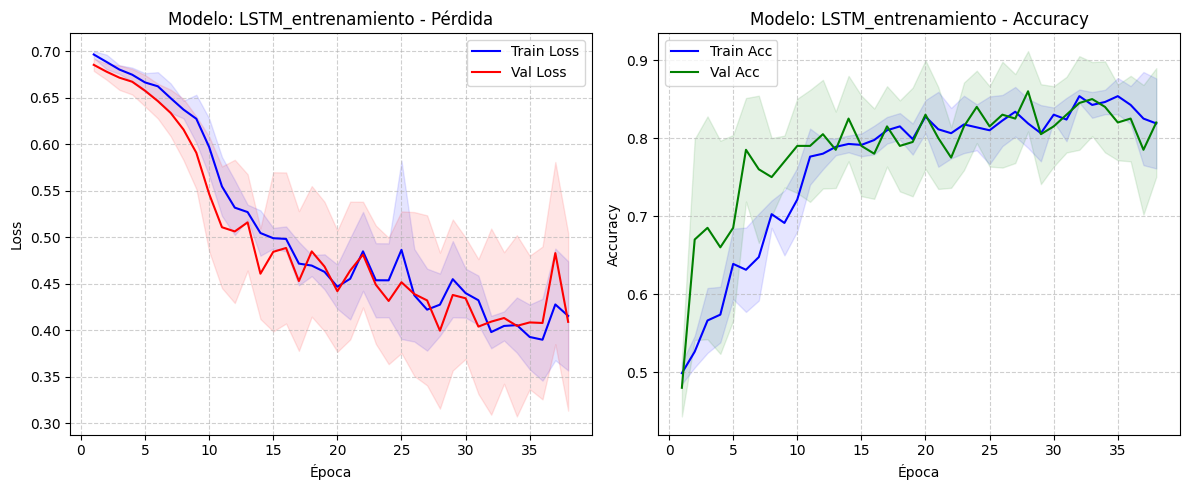

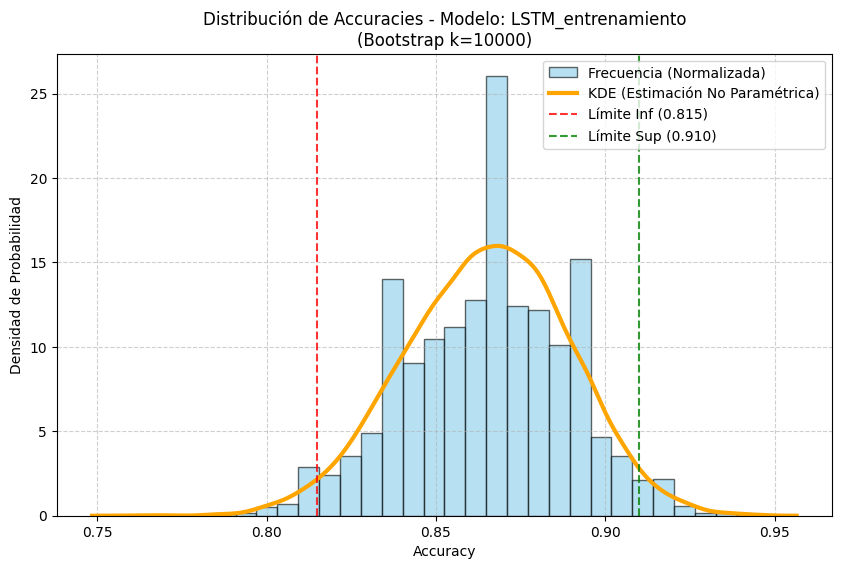

In [46]:
# Ejecución del Modelo Sencillo
ejecutar_experimento_individual(
    name='LSTM_entrenamiento', 
    lstm_layers=[128],
    dense_layers=[32],
    opt_name='adam', 
    dropout=0.2,    
    lr=0.0001,
    patience=10
)

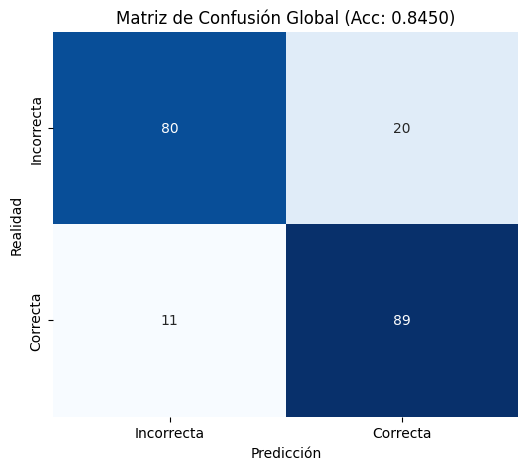


📋 Reporte de Clasificación:
              precision    recall  f1-score   support

  Incorrecta       0.88      0.80      0.84       100
    Correcta       0.82      0.89      0.85       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



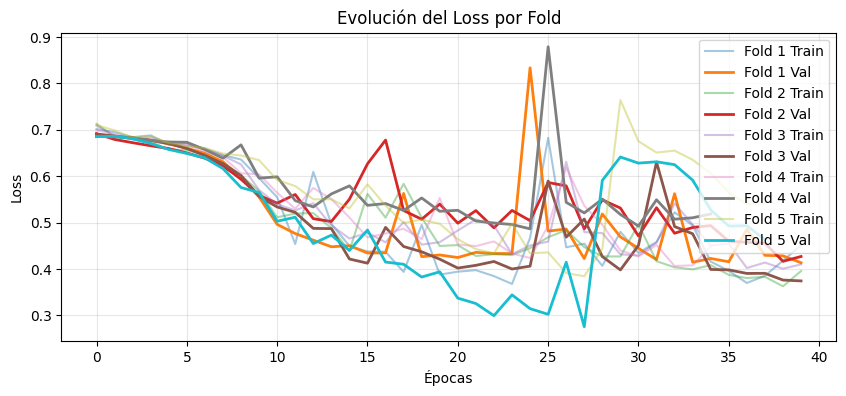

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(final_y_true, final_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Incorrecta', 'Correcta'],
            yticklabels=['Incorrecta', 'Correcta'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title(f'Matriz de Confusión Global (Acc: {mean_acc:.4f})')
plt.show()

### Experimento 2

🚀 INICIANDO: LSTM_Simple
   ⚙️ Arq: LSTM=[64] | Dense=[32]
   ⚙️ Params: Opt=adam | LR=0.001 | Drop=0.1 | Patience=0
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.7000 | Loss: 0.5258

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.5000 | Loss: 0.6838

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8000 | Loss: 0.4304

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.7500 | Loss: 0.5173

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.8250 | Loss: 0.3416
📊 Resultados GroupKFold:
| Accuracy Medio: 0.7150
| Desviación Std: 0.1158
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.7149
Intervalo de Confianza 95%: [0.6500, 0.7750]
   ✅ Resultado: Acc Promedio 0.7149 | IC 95%: [0.6500, 0.7750]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 40 épocas comunes...


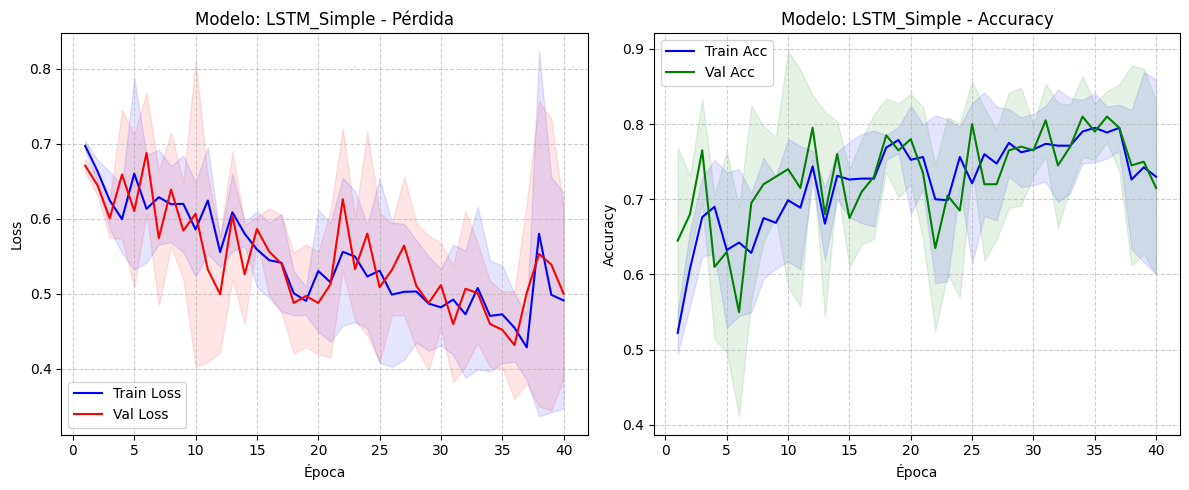

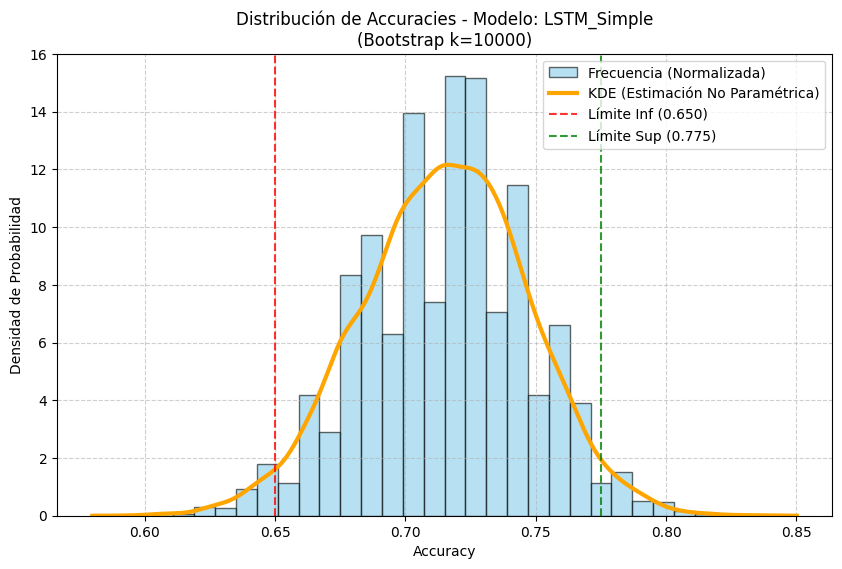

In [30]:
# Ejecución del Modelo Sencillo
ejecutar_experimento_individual(
    name='LSTM_Simple', 
    lstm_layers=[64],
    dense_layers=[32],
    opt_name='adam', 
    dropout=0.1,    
    lr=0.001,
    patience=0
)

### Experimento 3

🚀 INICIANDO: LSTM_02
   ⚙️ Arq: LSTM=[128, 64] | Dense=[32]
   ⚙️ Params: Opt=adam | LR=0.0001 | Drop=0.1 | Patience=0
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8750 | Loss: 0.3290

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.4304

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8750 | Loss: 0.3252

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8000 | Loss: 0.5098

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9000 | Loss: 0.3204
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8550
| Desviación Std: 0.0367
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8549
Intervalo de Confianza 95%: [0.8050, 0.9000]
   ✅ Resultado: Acc Promedio 0.8549 | IC 95%: [0.8050, 0.9000]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 40 épocas comunes...


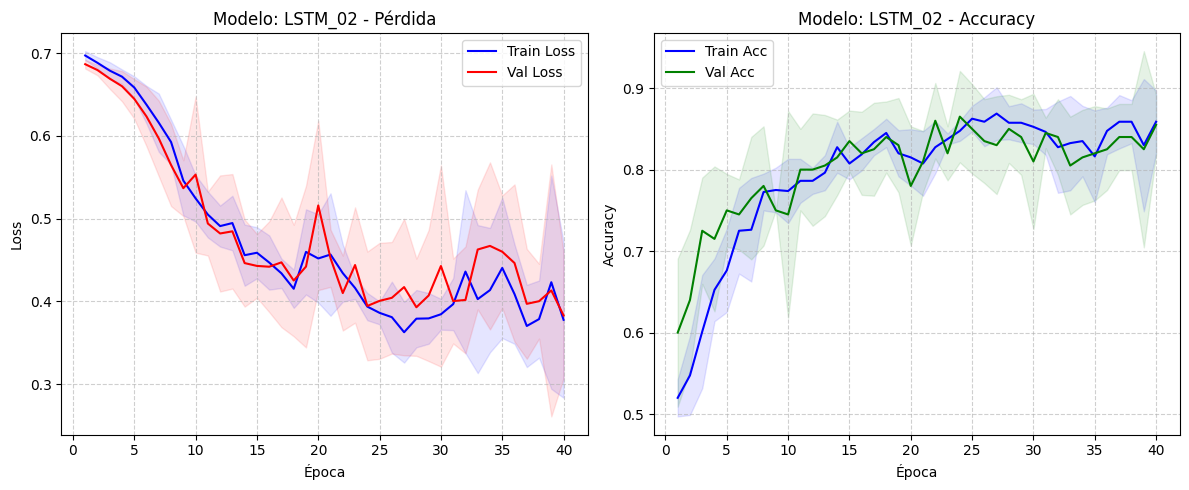

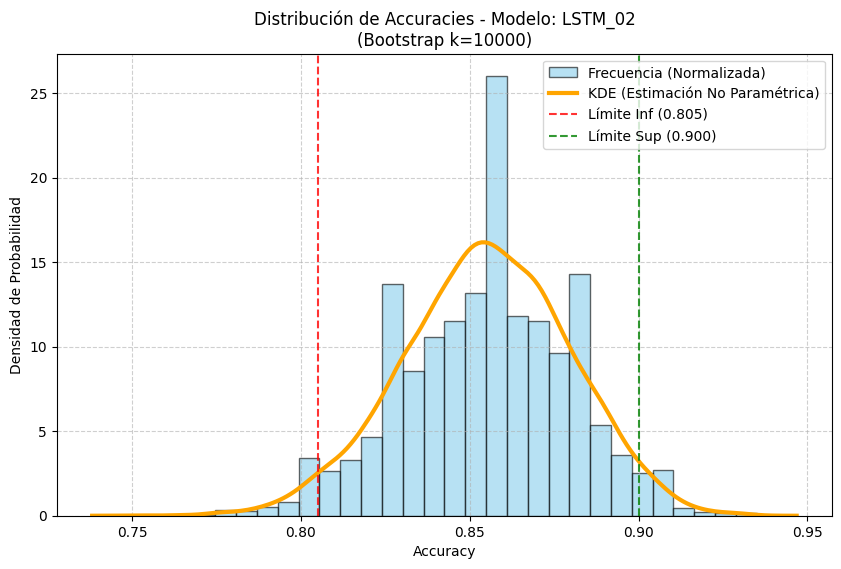

In [34]:
ejecutar_experimento_individual(
    name='LSTM_02', 
    lstm_layers=[128, 64],       # 2 capas LSTM
    dense_layers=[32],      # Una capa densa
    dropout=0.1, 
    lr=0.0001,
    opt_name='adam',        # Optimizador Adam
    patience=0,            # Sin Early Stopping 
    epochs=40
)

### Experimento 4

🚀 INICIANDO: 3_1Layer_Adam_NoEarlyStop
   ⚙️ Arq: LSTM=[64] | Dense=[32]
   ⚙️ Params: Opt=adam | LR=0.0005 | Drop=0.2 | Patience=0
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8750 | Loss: 0.6159

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.4235

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8500 | Loss: 0.4062

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.6500 | Loss: 0.6659

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.8500 | Loss: 0.4316
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8100
| Desviación Std: 0.0815
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8098
Intervalo de Confianza 95%: [0.7550, 0.8600]
   ✅ Resultado: Acc Promedio 0.8098 | IC 95%: [0.7550, 0.8600]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 40 épocas comunes...


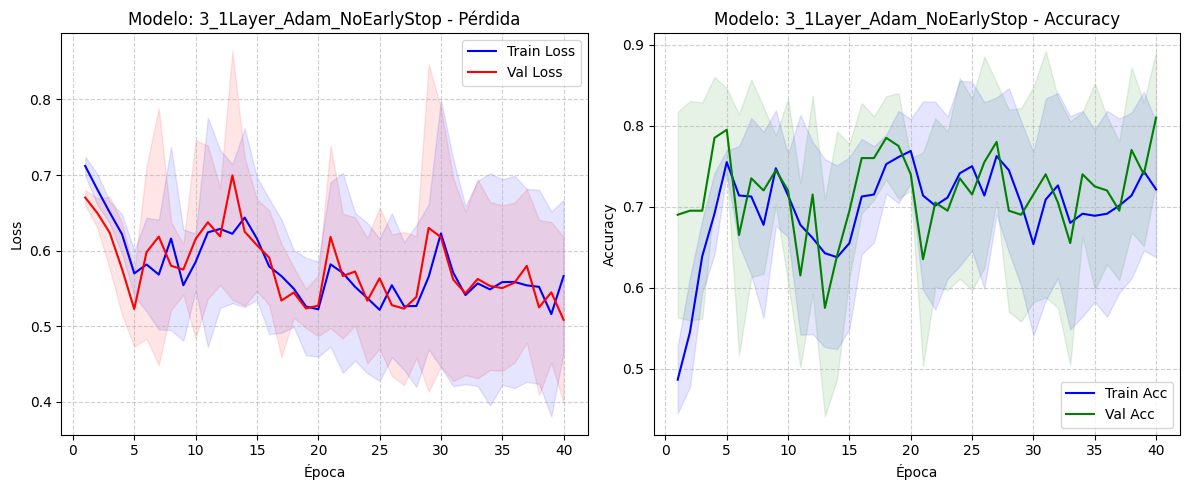

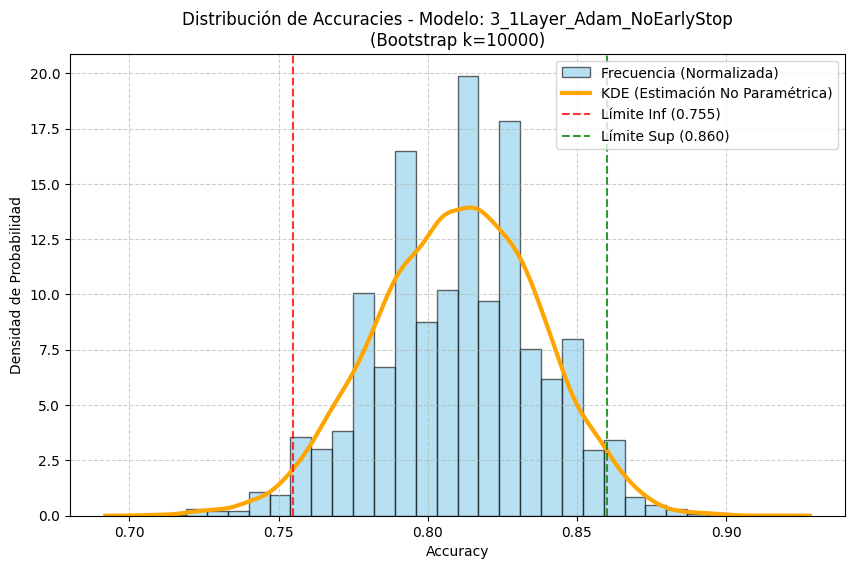

In [32]:
ejecutar_experimento_individual(
    name='3_1Layer_Adam_NoEarlyStop', 
    lstm_layers=[64],       # Una sola capa LSTM
    dense_layers=[32],      # Una capa densa
    dropout=0.2, 
    lr=0.0005,
    opt_name='adam',        # Optimizador Adam
    patience=0,            # Sin Early Stopping 
    epochs=40
)

### Experimento 5

🚀 INICIANDO: LSTM_Refinado_v1
   ⚙️ Arq: LSTM=[128, 64] | Dense=[64, 32]
   ⚙️ Params: Opt=adam | LR=0.0001 | Drop=0.2 | Patience=5
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4121

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8500 | Loss: 0.3873

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8500 | Loss: 0.4308

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8250 | Loss: 0.4824

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9250 | Loss: 0.3444
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8600
| Desviación Std: 0.0339
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8604
Intervalo de Confianza 95%: [0.8100, 0.9050]
   ✅ Resultado: Acc Promedio 0.8604 | IC 95%: [0.8100, 0.9050]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 16 épocas comunes...


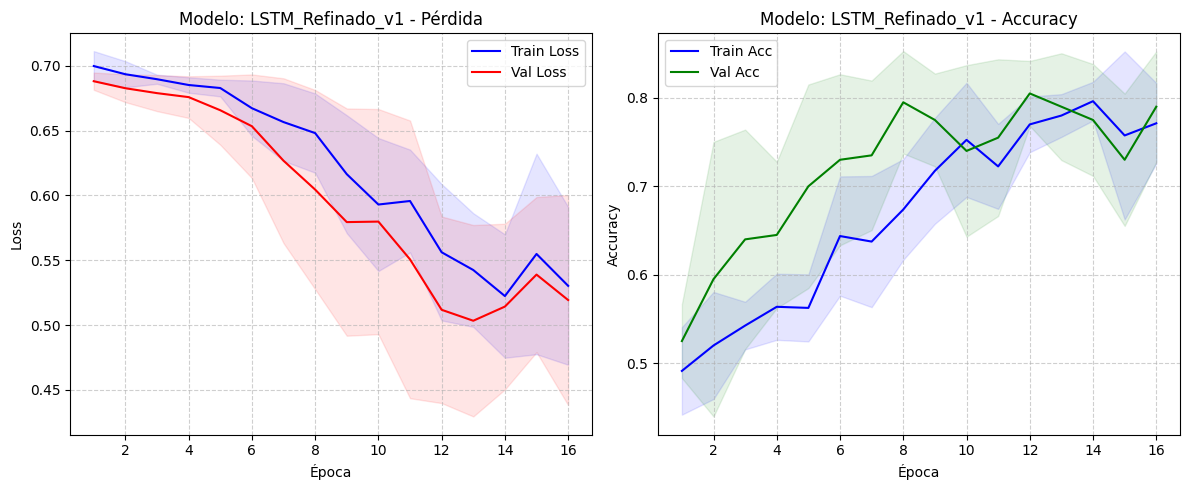

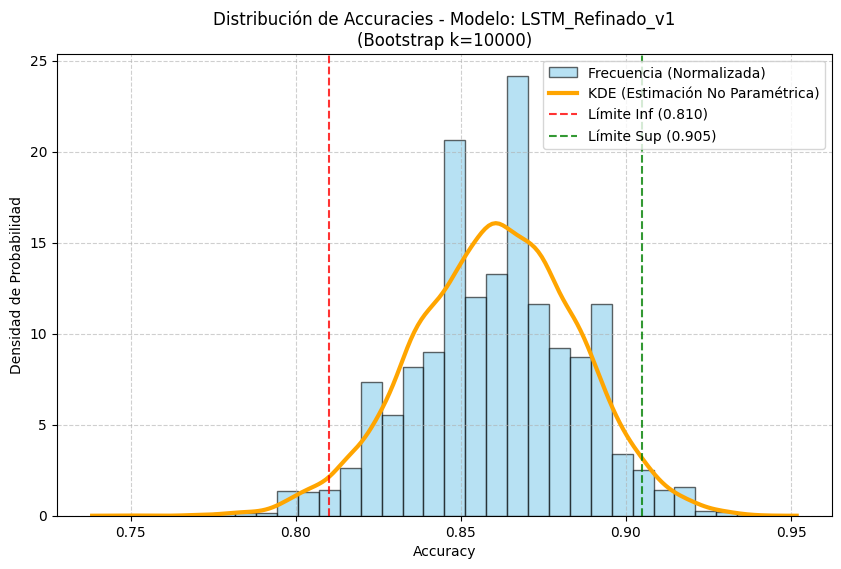

In [35]:
ejecutar_experimento_individual(
    name='LSTM_Refinado_v1', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],  # Añadir una capa densa más
    dropout=0.2,            # Ligeramente más regularización
    lr=0.0001,
    opt_name='adam',
    patience=5,             # Early stopping moderado
    epochs=60
)

### Experimento 6

🚀 INICIANDO: LSTM_Deep
   ⚙️ Arq: LSTM=[128, 64, 32] | Dense=[32]
   ⚙️ Params: Opt=adam | LR=0.0001 | Drop=0.15 | Patience=10
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4127

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.4127

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8250 | Loss: 0.4517

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8500 | Loss: 0.3833

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9250 | Loss: 0.2863
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8550
| Desviación Std: 0.0367
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8552
Intervalo de Confianza 95%: [0.8050, 0.9000]
   ✅ Resultado: Acc Promedio 0.8552 | IC 95%: [0.8050, 0.9000]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 31 épocas comunes...


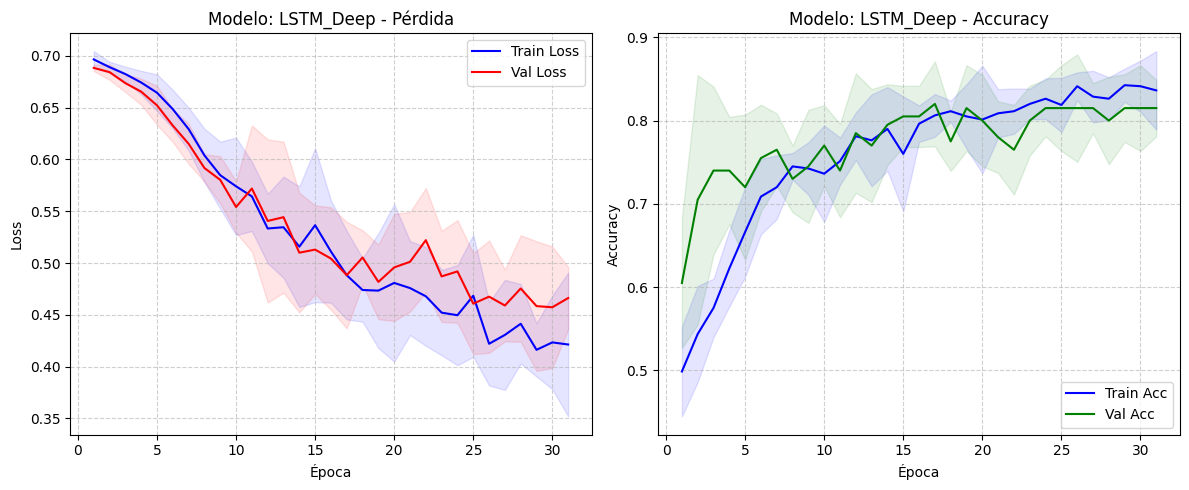

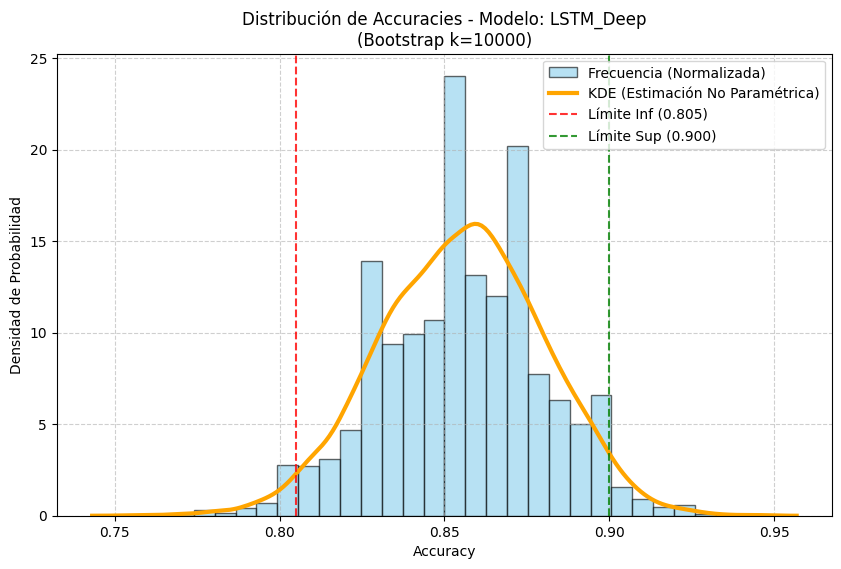

In [36]:
ejecutar_experimento_individual(
    name='LSTM_Deep', 
    lstm_layers=[128, 64, 32],  # 3 capas LSTM
    dense_layers=[32],
    dropout=0.15,
    lr=0.0001,
    opt_name='adam',
    patience=10,
    epochs=50
)

### Experimento 7

🚀 INICIANDO: LSTM_Wide
   ⚙️ Arq: LSTM=[256, 64] | Dense=[32]
   ⚙️ Params: Opt=adam | LR=5e-05 | Drop=0.2 | Patience=10
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.3975

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8250 | Loss: 0.3893

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.9250 | Loss: 0.2249

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8250 | Loss: 0.4550

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9000 | Loss: 0.2855
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8650
| Desviación Std: 0.0406
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8652
Intervalo de Confianza 95%: [0.8150, 0.9100]
   ✅ Resultado: Acc Promedio 0.8652 | IC 95%: [0.8150, 0.9100]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 42 épocas comunes...


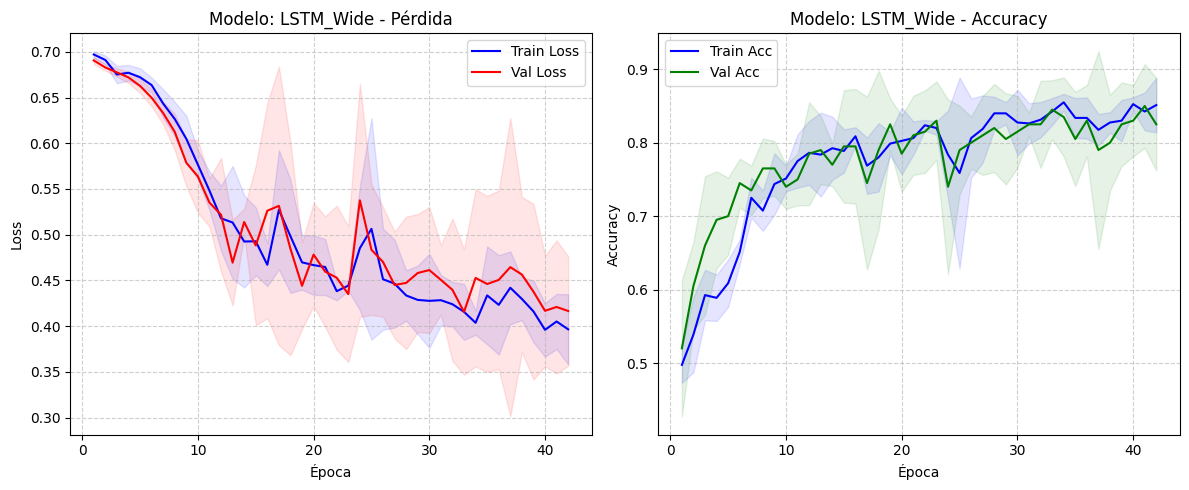

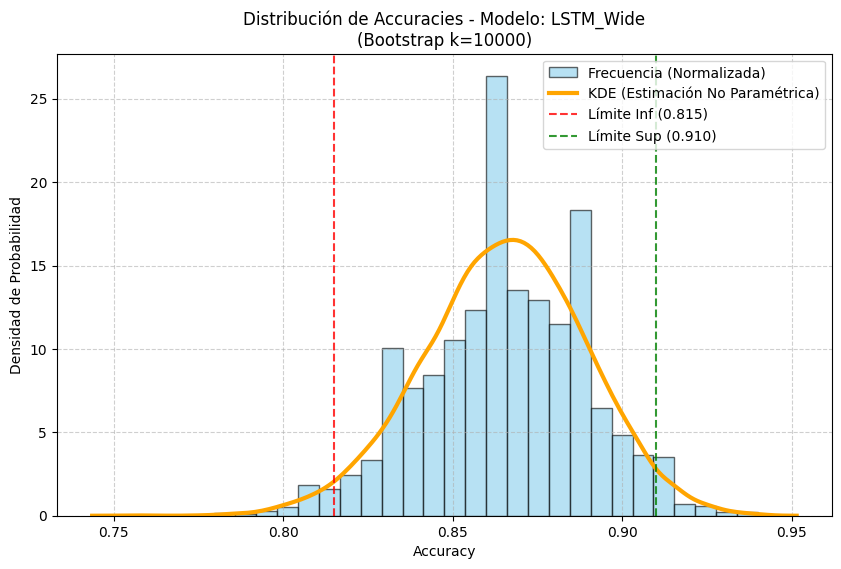

In [37]:
ejecutar_experimento_individual(
    name='LSTM_Wide', 
    lstm_layers=[256, 64],
    dense_layers=[32],
    dropout=0.2,
    lr=0.00005,             # LR más bajo para más unidades
    opt_name='adam',
    patience=10,
    epochs=60
)

### Experimento 8

🚀 INICIANDO: LSTM_Regularized
   ⚙️ Arq: LSTM=[128, 64] | Dense=[32]
   ⚙️ Params: Opt=adamw | LR=0.0001 | Drop=0.3 | Patience=10
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.3947

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8500 | Loss: 0.3351

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.9000 | Loss: 0.2943

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8000 | Loss: 0.4626

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9500 | Loss: 0.2226
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8700
| Desviación Std: 0.0510
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8699
Intervalo de Confianza 95%: [0.8200, 0.9150]
   ✅ Resultado: Acc Promedio 0.8699 | IC 95%: [0.8200, 0.9150]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 38 épocas comunes...


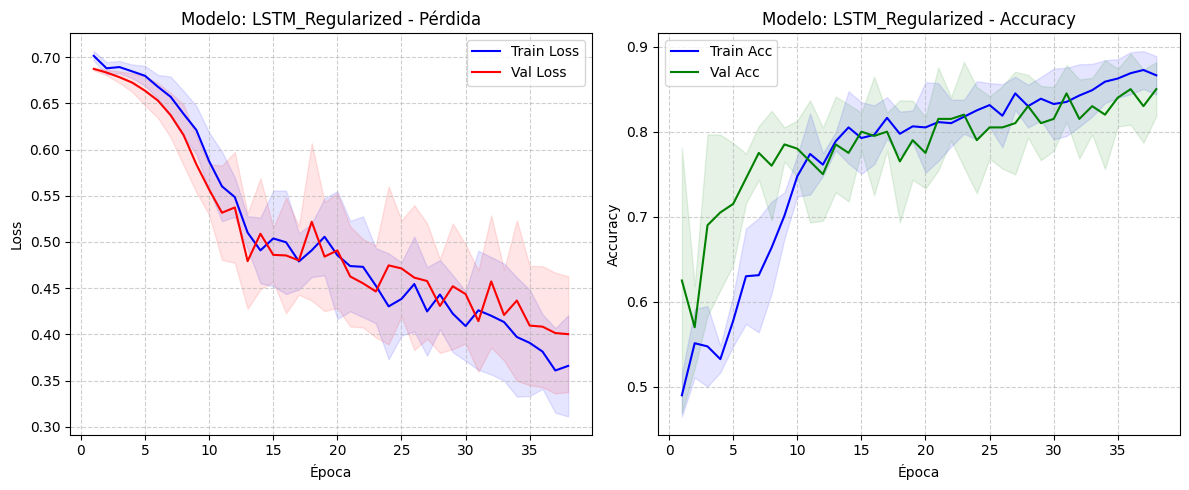

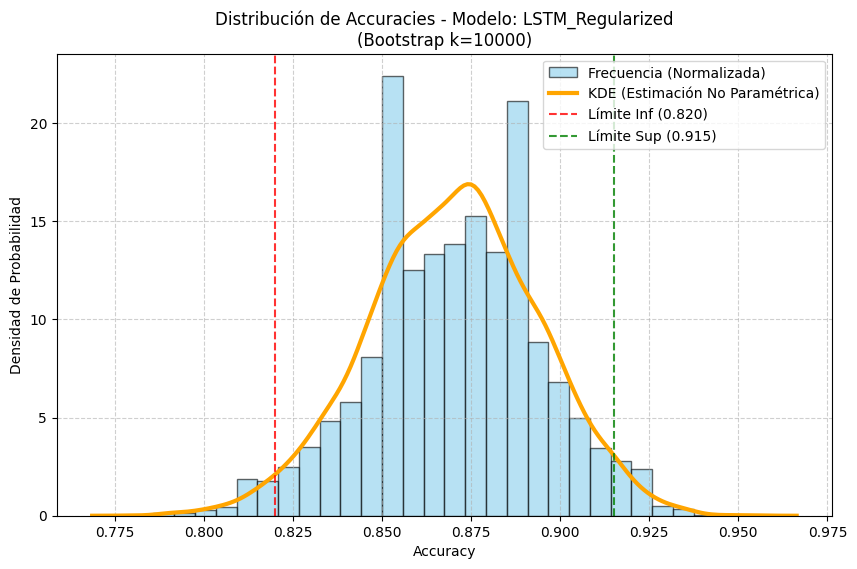

In [38]:
ejecutar_experimento_individual(
    name='LSTM_Regularized', 
    lstm_layers=[128, 64],
    dense_layers=[32],
    dropout=0.3,
    lr=0.0001,
    opt_name='adamw',       # AdamW tiene weight decay incorporado
    patience=10,
    epochs=50
)

### Experimento 9

🚀 INICIANDO: LSTM_Wide_v2
   ⚙️ Arq: LSTM=[256, 128] (Bi=False) | Dense=[64, 32]
   ⚙️ Params: Opt=adam | LR=5e-05 | Drop=0.3 | Patience=15
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.9000 | Loss: 0.2828

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8750 | Loss: 0.2443

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8250 | Loss: 0.4159

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8500 | Loss: 0.3035

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9500 | Loss: 0.2330
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8800
| Desviación Std: 0.0430
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8802
Intervalo de Confianza 95%: [0.8350, 0.9250]
   ✅ Resultado: Acc Promedio 0.8802 | IC 95%: [0.8350, 0.9250]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 43 épocas comunes...


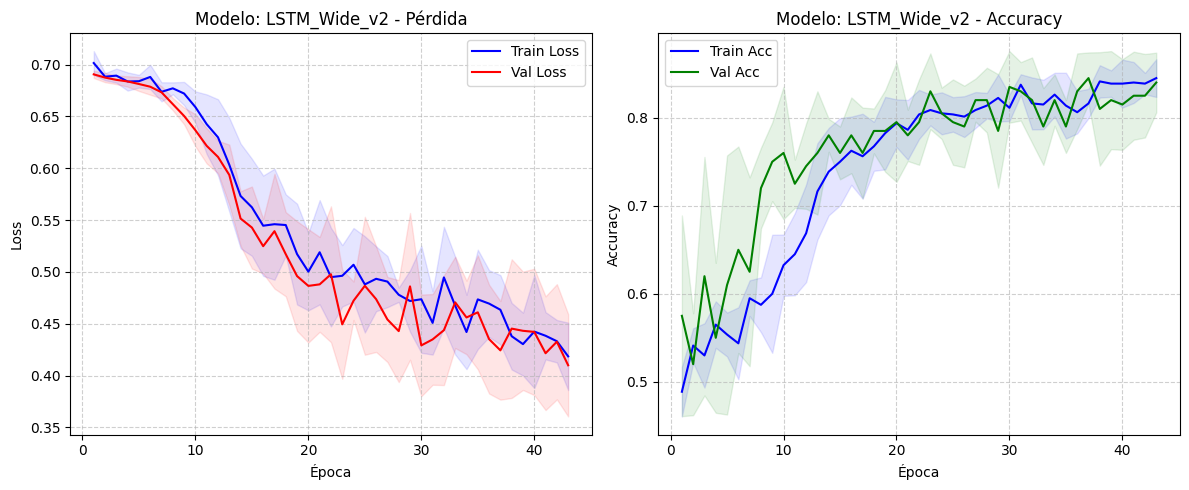

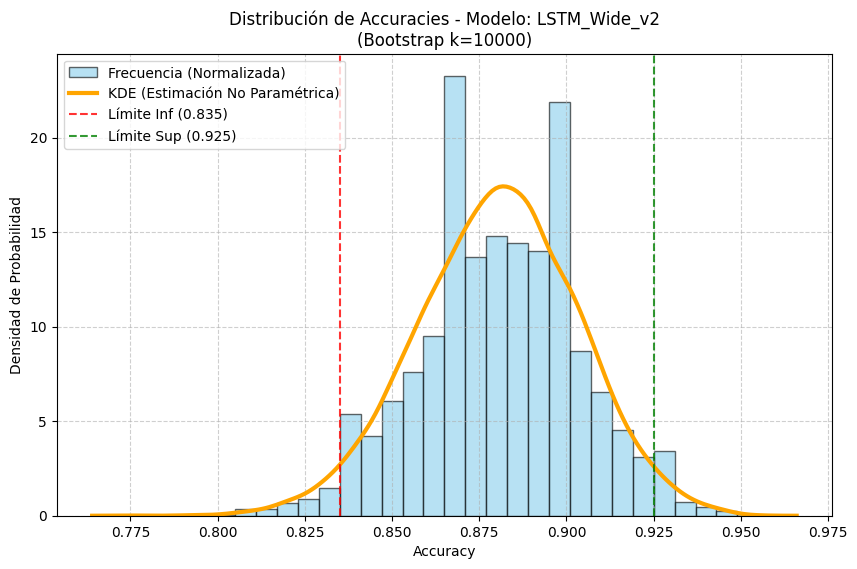

In [42]:
ejecutar_experimento_individual(
    name='LSTM_Wide_v2', 
    lstm_layers=[256, 128],
    dense_layers=[64, 32],
    dropout=0.3,
    lr=0.00005,
    opt_name='adam',
    patience=15,
    epochs=80
)

### Experimento 10

🚀 INICIANDO: LSTM_LongTrain
   ⚙️ Arq: LSTM=[128, 64] (Bi=False) | Dense=[64, 32]
   ⚙️ Params: Opt=adam | LR=5e-05 | Drop=0.2 | Patience=15
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4285

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.9000 | Loss: 0.2607

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8750 | Loss: 0.3377

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8500 | Loss: 0.3745

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9250 | Loss: 0.2719
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8800
| Desviación Std: 0.0292
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8799
Intervalo de Confianza 95%: [0.8300, 0.9250]
   ✅ Resultado: Acc Promedio 0.8799 | IC 95%: [0.8300, 0.9250]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 50 épocas comunes...


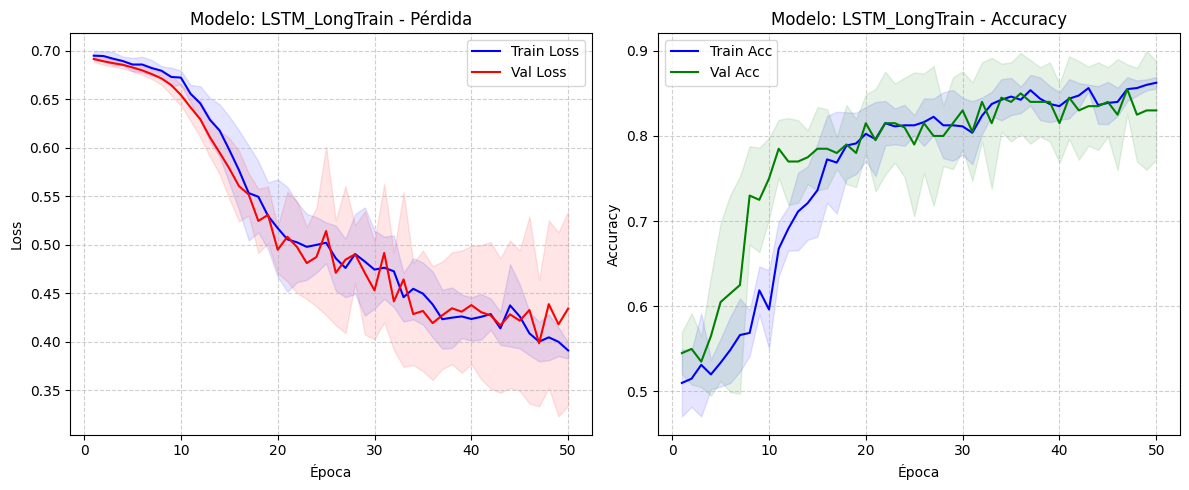

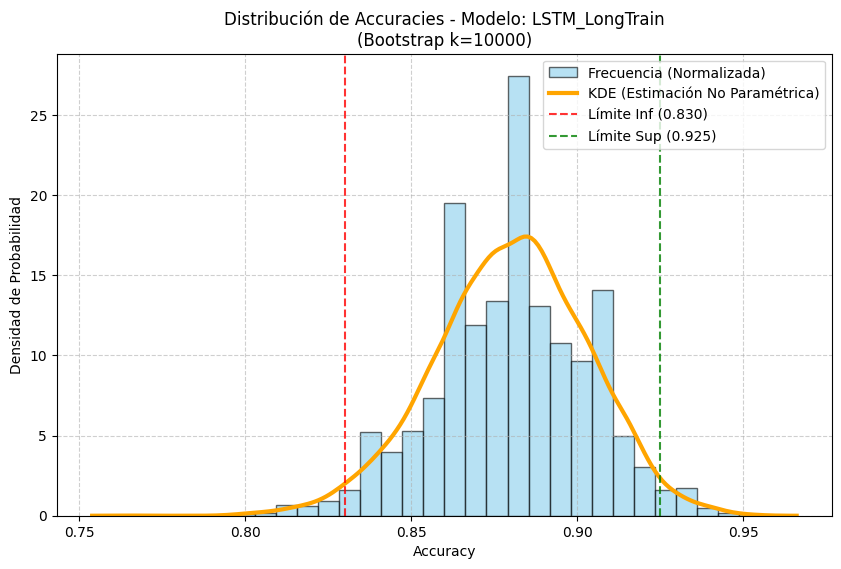

In [43]:
ejecutar_experimento_individual(
    name='LSTM_LongTrain', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.2,
    lr=0.00005,            # LR más bajo
    opt_name='adam',
    patience=15,           # Más paciencia
    epochs=100             # Más épocas para converger
)

### Experimento 11 - Bidireccional

🚀 INICIANDO: BiLSTM_v1
   ⚙️ Arq: LSTM=[128, 64] (Bi=True) | Dense=[64, 32]
   ⚙️ Params: Opt=adam | LR=0.0001 | Drop=0.25 | Patience=10
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.8500 | Loss: 0.4180

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.7500 | Loss: 0.5650

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.8750 | Loss: 0.3763

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8500 | Loss: 0.2762

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.9750 | Loss: 0.1286
📊 Resultados GroupKFold:
| Accuracy Medio: 0.8600
| Desviación Std: 0.0718
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.8597
Intervalo de Confianza 95%: [0.8100, 0.9050]
   ✅ Resultado: Acc Promedio 0.8597 | IC 95%: [0.8100, 0.9050]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 21 épocas comunes...


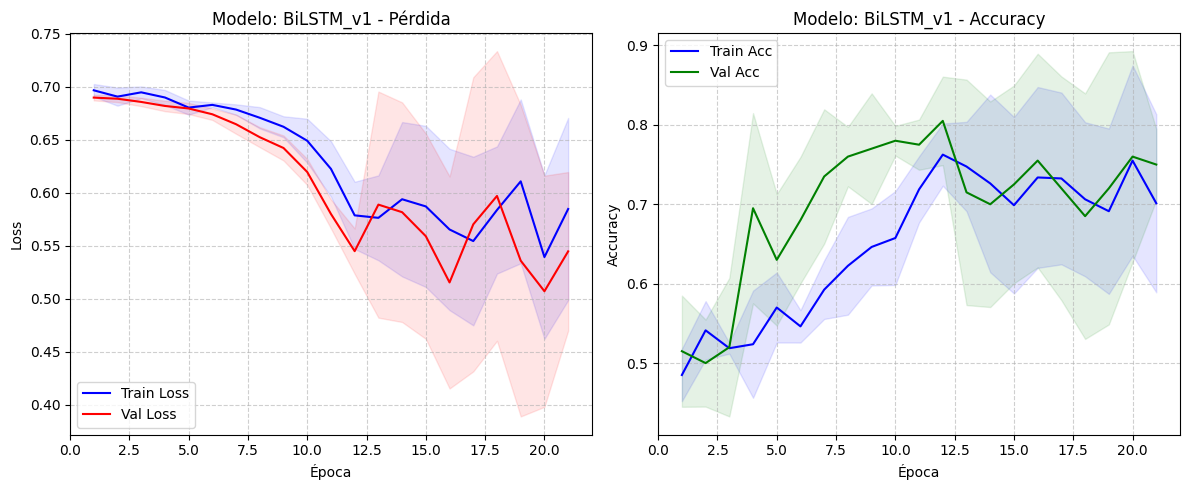

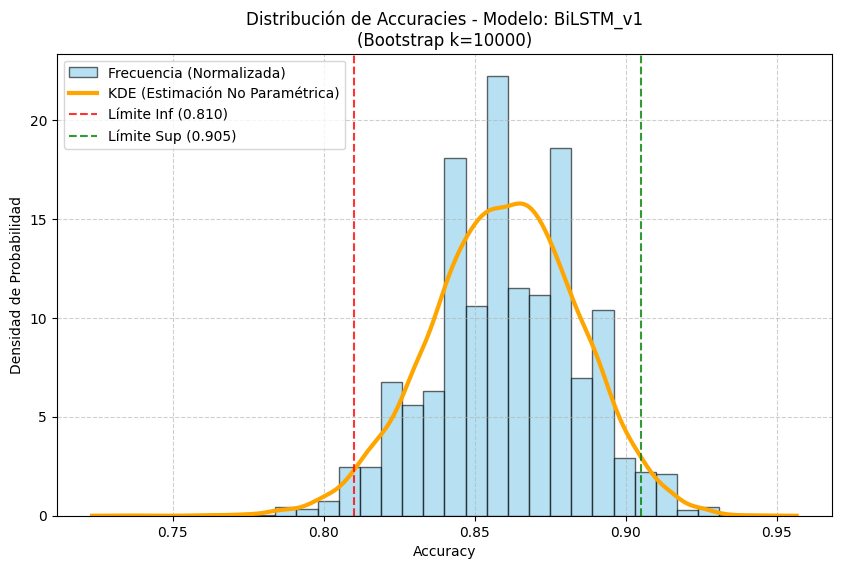

In [41]:
ejecutar_experimento_individual(
    name='BiLSTM_v1', 
    lstm_layers=[128, 64],
    dense_layers=[64, 32],
    dropout=0.25,
    lr=0.0001,
    opt_name='adam',
    bidirectional=True,     # LSTM bidireccional
    patience=10,
    epochs=80
)

## Experimentación con aumentación y datos angulares 

In [51]:
import numpy as np

# 1. Cargar datos (Asegúrate de que las rutas sean correctas)
X_correct_mirrored = np.load('../Data/Processed/mirrored_correct_push_ups_angles.npy')
X_incorrect_mirrored = np.load('../Data/Processed/mirrored_wrong_push_ups_angles.npy')
X_correct_original = np.load('../Data/Processed/correct_push_ups_angles.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_angles.npy')

# 2. Concatenar clases para formar X e y (Mirrored y Original por separado primero)
# MIRRORED
X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*len(X_correct_mirrored) + [0]*len(X_incorrect_mirrored))

# ORIGINAL
X_original = np.vstack((X_correct_original, X_incorrect_original))
y_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# 3. CREACIÓN DE LOS GRUPOS (La parte clave)
# Asumimos que el video i-ésimo de X_original corresponde al video i-ésimo de X_mirrored
# Creamos un ID único para cada video original
original_ids = np.arange(len(X_original))
mirrored_ids = np.arange(len(X_mirrored)) # Debería ser igual al anterior si están ordenados

# 4. JUNTAR TODO (Original + Mirrored)
X_total = np.concatenate((X_original, X_mirrored), axis=0)
y_total = np.concatenate((y_original, y_mirrored), axis=0)

# El array 'groups' le dice al KFold qué filas son "hermanas"
groups = np.concatenate((original_ids, mirrored_ids), axis=0) # evita fugas de datos, usa el mismo video original y espejado en el mismo conjunto (no el original en train y el espejado en val por ejemplo)

print(f"Forma de X_total: {X_total.shape}")
print(f"Forma de y_total: {y_total.shape}")
print(f"Forma de groups: {groups.shape}")
print(f"Ejemplo: El dato en índice 0 (orig) y el índice {len(X_original)} (mirror) tienen el grupo {groups[0]} y {groups[len(X_original)]}")

Forma de X_total: (200, 160, 10)
Forma de y_total: (200,)
Forma de groups: (200,)
Ejemplo: El dato en índice 0 (orig) y el índice 100 (mirror) tienen el grupo 0 y 0


### Experimento 12

🚀 INICIANDO: LSTM_Wide_Angles_v2
   ⚙️ Arq: LSTM=[256, 128] (Bi=False) | Dense=[64, 32]
   ⚙️ Params: Opt=adam | LR=5e-05 | Drop=0.3 | Patience=15
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.9500 | Loss: 0.1090

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.9750 | Loss: 0.1165

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 1.0000 | Loss: 0.0098

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.9500 | Loss: 0.2207

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 1.0000 | Loss: 0.0204
📊 Resultados GroupKFold:
| Accuracy Medio: 0.9750
| Desviación Std: 0.0224
   🎲 Calculando Bootstrap (10,000 iteraciones)...
Accuracy Promedio (Bootstrap): 0.9749
Intervalo de Confianza 95%: [0.9500, 0.9950]
   ✅ Resultado: Acc Promedio 0.9749 | IC 95%: [0.9500, 0.9950]

📈 Generando curvas de aprendizaje promedio...
Graficando las primeras 60 épocas comunes...


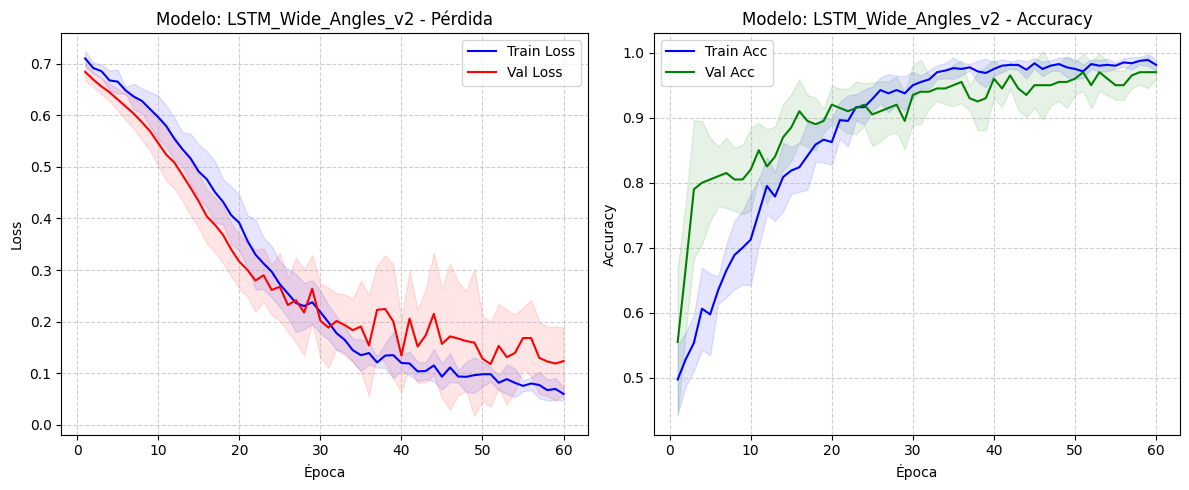

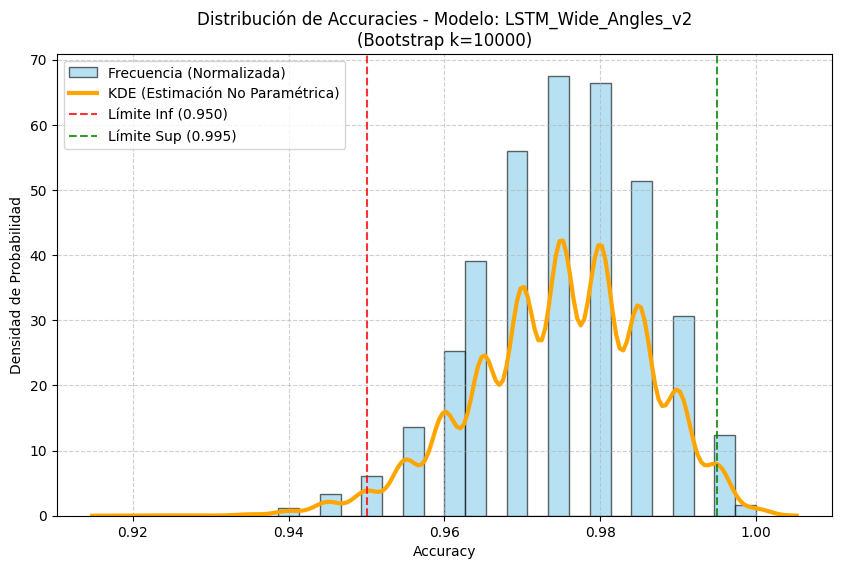

In [53]:
ejecutar_experimento_individual(
    name='LSTM_Wide_Angles_v2', 
    lstm_layers=[256, 128],
    dense_layers=[64, 32],
    dropout=0.3,
    lr=0.00005,
    opt_name='adam',
    patience=15,
    epochs=80
)

## Experimentación sin aumentación con Landmarks 

Para esta experimentación, adaptaremos nuestra función de ejecutar expermientos para no modificarla 

In [54]:
import numpy as np

# 1. Cargar lo de siempre
X_correct_original = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect_original = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

# 2. Crear el dataset "SOLO ORIGINAL" (Sin espejos)
X_test_original = np.vstack((X_correct_original, X_incorrect_original))
y_test_original = np.array([1]*len(X_correct_original) + [0]*len(X_incorrect_original))

# 3. Grupos simples (Cada video es un grupo porque no hay espejos)
groups_original = np.arange(len(X_test_original))

print("🧪 Datos para prueba SIN ESPEJOS preparados:")
print(f"   X: {X_test_original.shape}")
print(f"   y: {y_test_original.shape}")

🧪 Datos para prueba SIN ESPEJOS preparados:
   X: (100, 160, 66)
   y: (100,)


In [55]:
def ejecutar_experimento_sin_aumentación(name, lstm_layers, dense_layers, dropout, lr, 
                                         opt_name, patience, bidirectional=False, 
                                         epochs=40, batch_size=16):
    
    print(f"⚠️ EJECUTANDO TEST DE SOLO ORIGINALES (SIN DATA AUGMENTATION)")
    print(f"🚀 INICIANDO EXP: {name}")
    print("-" * 60)
    
    # Builder (Igual)
    model_builder = lambda t, f: create_custom_lstm(
        t, f, 
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        dropout_rate=dropout, 
        learning_rate=lr,
        optimizer_name=opt_name,
        bidirectional=bidirectional
    )
    
    # --- AQUÍ ESTÁ EL ÚNICO CAMBIO ---
    # En vez de usar X_total, forzamos el uso de X_test_original
    mean_acc, std_acc, histories, final_y_true, final_y_pred = run_kfold_experiment(
        model_fn=model_builder,
        X_train=X_test_original,     # <--- CAMBIO: Datos limpios
        y_train=y_test_original,     # <--- CAMBIO: Etiquetas limpias
        groups=groups_original,      # <--- CAMBIO: Grupos simples
        epochs=epochs, batch_size=batch_size, n_splits=5, patience=patience 
    )
    # ---------------------------------

    # Gráficas
    print("\n📈 Curvas de aprendizaje (Solo Originales)...")
    plot_kfold_history_keras(histories, title=f'{name} (Originales)')

    # Bootstrap
    print(f"🎲 Calculando Bootstrap...")
    lower, upper, stats = calcular_bootstrap_intervalo(final_y_true, final_y_pred, n_iterations=10000)
    boot_mean = np.mean(stats)
    
    # Guardar en la tabla GLOBAL (Avisando en el nombre)
    global results_table
    # Añadimos etiqueta al nombre para diferenciarlo en la tabla
    name_tagged = name + "_SOLO_ORIGINAL"
    
    results_table.append({
        'Modelo': name_tagged,      # <--- Lo guardamos con nombre distinto
        'Dataset': 'SOLO_ORIGINAL', # <--- Etiqueta clara
        'Acc CV': mean_acc,
        'Acc Boot': boot_mean,
        'IC 95%': f"[{lower:.3f}-{upper:.3f}]",
        'LSTM Layers': str(lstm_layers), 
        'Bidirectional': bidirectional,
        'Epochs': epochs
    })
    
    print(f"✅ Guardado como '{name_tagged}'. Acc: {boot_mean:.4f}")
    print("=" * 60)

### Experimento 13

⚠️ EJECUTANDO TEST DE SOLO ORIGINALES (SIN DATA AUGMENTATION)
🚀 INICIANDO EXP: Validacion_Sin_Espejos
------------------------------------------------------------
🚀 Iniciando GroupKFold Keras (5 splits)...
   Protección contra Data Leakage activa (Grupos detectados: 100)

🔄 Pliegue 1/5


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    ✅ Fin Fold 1. Acc Val: 0.7500 | Loss: 0.4969

🔄 Pliegue 2/5
    ✅ Fin Fold 2. Acc Val: 0.8500 | Loss: 0.3640

🔄 Pliegue 3/5
    ✅ Fin Fold 3. Acc Val: 0.6000 | Loss: 0.5950

🔄 Pliegue 4/5
    ✅ Fin Fold 4. Acc Val: 0.8000 | Loss: 0.4433

🔄 Pliegue 5/5
    ✅ Fin Fold 5. Acc Val: 0.8000 | Loss: 0.4618
📊 Resultados GroupKFold:
| Accuracy Medio: 0.7600
| Desviación Std: 0.0860

📈 Curvas de aprendizaje (Solo Originales)...
Graficando las primeras 21 épocas comunes...


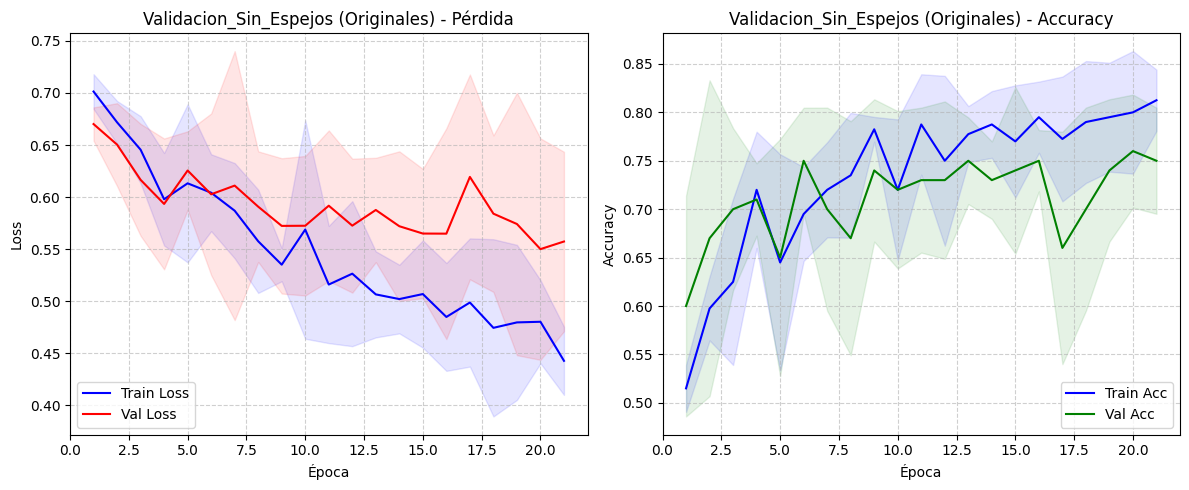

🎲 Calculando Bootstrap...
Accuracy Promedio (Bootstrap): 0.7596
Intervalo de Confianza 95%: [0.6700, 0.8400]
✅ Guardado como 'Validacion_Sin_Espejos_SOLO_ORIGINAL'. Acc: 0.7596


In [56]:
# Probamos la mejor configuración pero SIN los datos espejo
ejecutar_experimento_sin_aumentación(
    name='Validacion_Sin_Espejos', 
    lstm_layers=[64],  # (Pon aquí la config ganadora)
    dense_layers=[32], 
    bidirectional=True,
    dropout=0.2, 
    lr=0.001, 
    opt_name='adam', 
    patience=15
)